In [ ]:
import subprocess
import os
import csv
import statistics
 
os.makedirs("results", exist_ok=True)
 
urls_file = "urls.txt"
keyword = "fakulteta"
 
def parse_times(stdout):
    times = []
 
    for line in stdout.splitlines():
        line = line.strip()
 
        if line.startswith("Run"):
            parts = line.split(":")
            run_number = int(parts[0].split()[1])
            elapsed_time = float(parts[1].split()[0])
            times.append((run_number, elapsed_time))
    return times
 
 
def save_csv(csv_path, rows):
    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow([
            "program",
            "run_number",
            "elapsed_time_s",
            "nprocs"
        ])
        writer.writerows(rows)
 
 
def print_summary(program, times, nprocs):
    values = [t for _, t in times]
    avg = statistics.mean(values)
    std = statistics.stdev(values) if len(values) > 1 else 0.0
    min_time = min(values)
    max_time = max(values)
 
    print(f"\n--- Povzetek: {program}, nprocs={nprocs} ---")
    print(f"Povprečni čas:      {avg:.4f} s")
    print(f"Standardni odklon:  {std:.4f} s")
    print(f"Minimalni čas:      {min_time:.4f} s")
    print(f"Maksimalni čas:     {max_time:.4f} s")
 
 
# 1) Serial
script = "WebScraperSerial.py"
csv_path = os.path.join("results", "WebScraperSerial.csv")
 
print(f"\nRunning {script}")
 
cmd = ["python", script, urls_file, keyword]
result = subprocess.run(cmd, capture_output=True, text=True)
 
print(result.stdout)
 
if result.stderr:
    print("STDERR:")
    print(result.stderr)
 
times = parse_times(result.stdout)
 
rows = []
for run_number, elapsed_time in times:
    rows.append([script, run_number, elapsed_time, 1])
 
save_csv(csv_path, rows)
print_summary(script, times, 1)
 
print(f"Shranjeno: {csv_path}")
 
 
# 2) Numba
script = "WebSerialNumba.py"
csv_path = os.path.join("results", "WebSerialNumba.csv")
 
print(f"\nRunning {script}")
 
cmd = ["python", script, urls_file, keyword]
result = subprocess.run(cmd, capture_output=True, text=True)
 
print(result.stdout)
 
if result.stderr:
    print("STDERR:")
    print(result.stderr)
 
times = parse_times(result.stdout)
 
rows = []
for run_number, elapsed_time in times:
    rows.append([script, run_number, elapsed_time, 1])
 
save_csv(csv_path, rows)
print_summary(script, times, 1)
 
print(f"Shranjeno: {csv_path}")
 
 
# 3) MPI
script = "WebScraperMPI.py"
csv_path = os.path.join("results", "WebScraperMPI.csv")
 
all_mpi_rows = []
 
for nprocs in [1, 2, 4, 8]:
    print(f"\nRunning {script} with {nprocs} processes")
 
    cmd = [
        "mpiexec",
        "-n",
        str(nprocs),
        "python",
        script,
        urls_file,
        keyword
    ]
 
    result = subprocess.run(cmd, capture_output=True, text=True)
 
    print(result.stdout)
 
    if result.stderr:
        print("STDERR:")
        print(result.stderr)
 
    times = parse_times(result.stdout)
 
    for run_number, elapsed_time in times:
        all_mpi_rows.append([script, run_number, elapsed_time, nprocs])
 
    print_summary(script, times, nprocs)
 
save_csv(csv_path, all_mpi_rows)
 
print(f"Shranjeno: {csv_path}")


Running WebScraperSerial.py
Run  1: 3.5635 s
Run  2: 2.0895 s
Run  3: 4.8005 s
Run  4: 3.4262 s
Run  5: 1.7727 s
Run  6: 1.6342 s
Run  7: 2.9053 s
Run  8: 3.8605 s
Run  9: 5.8487 s
Run 10: 5.2022 s

--- Povzetek ÄŤasa ---
Povprecni cas: 3.5103 s
Standardni odklon: 1.3803 s
Minimalni cas: 1.6342 s
Maximalni cas: 5.8487 s


--- Povzetek: WebScraperSerial.py, nprocs=1 ---
Povprečni čas:      3.5103 s
Standardni odklon:  1.4549 s
Minimalni čas:      1.6342 s
Maksimalni čas:     5.8487 s
Shranjeno: results\WebScraperSerial.csv

Running WebSerialNumba.py
Run  1: 2.8667 s
Run  2: 3.3509 s
Run  3: 5.6749 s
Run  4: 4.4140 s
Run  5: 4.5766 s
Run  6: 2.6587 s
Run  7: 5.0066 s
Run  8: 2.5561 s
Run  9: 3.3739 s
Run 10: 2.9338 s

--- Povzetek casa ---
Povprecni cas: 3.7412 s
Standardni odklon: 1.0379 s
Minimalni cas: 2.5561 s
Maximalni cas: 5.6749 s


--- Povzetek: WebSerialNumba.py, nprocs=1 ---
Povprečni čas:      3.7412 s
Standardni odklon:  1.0940 s
Minimalni čas:      2.5561 s
Maksimalni čas: 

# Rezultati - graf

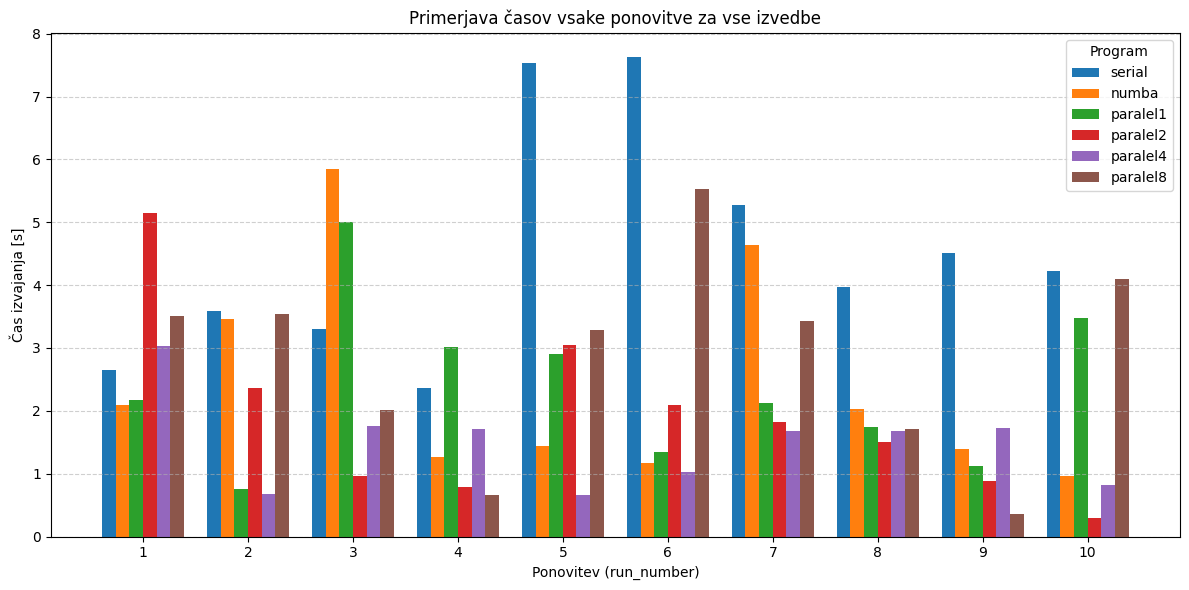

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

runs = np.arange(1, 11)

serial_times = [2.6546, 3.5825, 3.3060, 2.3598, 7.5290, 7.6314, 5.2709, 3.9749, 4.5172, 4.2234]
numba_times  = [2.0920, 3.4537, 5.8501, 1.2610, 1.4335, 1.1635, 4.6385, 2.0317, 1.3869, 0.9625]
paralel1_times = [2.1707, 0.7526, 5.0014, 3.0122, 2.9059, 1.3465, 2.1183, 1.7438, 1.1228, 3.4830]
paralel2_times = [5.1511, 2.3617, 0.9638, 0.7836, 3.0513, 2.0939, 1.8158, 1.5116, 0.8791, 0.2990]
paralel4_times = [3.0338, 0.6815, 1.7606, 1.7179, 0.6610, 1.0307, 1.6864, 1.6825, 1.7201, 0.8257]
paralel8_times = [3.5092, 3.5480, 2.0173, 0.6583, 3.2861, 5.5352, 3.4241, 1.7179, 0.3596, 4.1034]

width = 0.13
x = np.arange(len(runs))

plt.figure(figsize=(12,6))

plt.bar(x - 2.5*width, serial_times, width=width, label='serial')
plt.bar(x - 1.5*width, numba_times, width=width, label='numba')
plt.bar(x - 0.5*width, paralel1_times, width=width, label='paralel1')
plt.bar(x + 0.5*width, paralel2_times, width=width, label='paralel2')
plt.bar(x + 1.5*width, paralel4_times, width=width, label='paralel4')
plt.bar(x + 2.5*width, paralel8_times, width=width, label='paralel8')

plt.xlabel("Ponovitev (run_number)")
plt.ylabel("Čas izvajanja [s]")
plt.title("Primerjava časov vsake ponovitve za vse izvedbe")
plt.xticks(x, runs)
plt.legend(title="Program")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

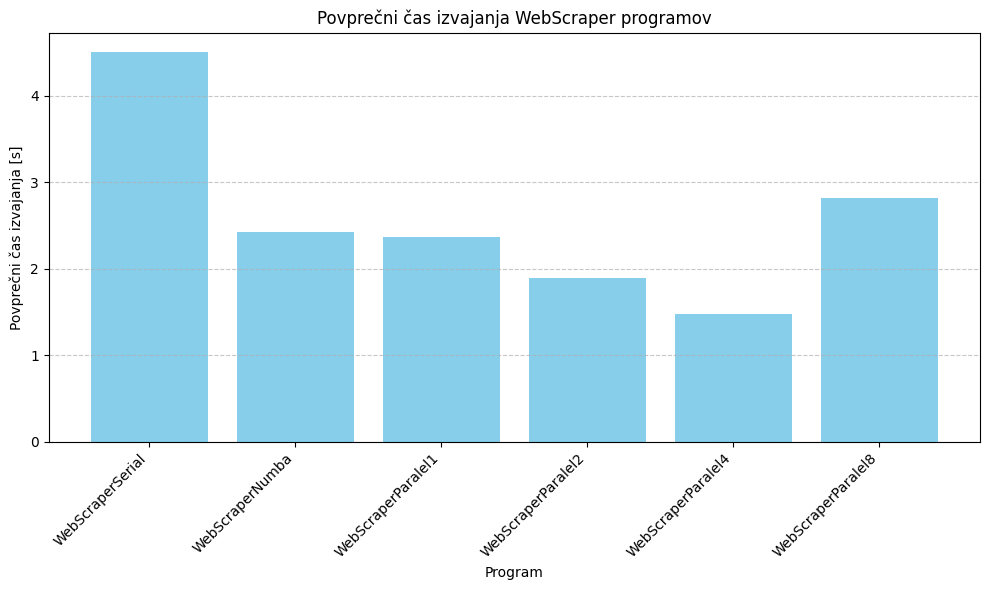

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import re

# Seznam CSV-jev
csv_files = [
    "results/WebScraperSerial.csv",
    "results/WebScraperNumba.csv",
    "results/WebScraperParalel1.csv",
    "results/WebScraperParalel2.csv",
    "results/WebScraperParalel4.csv",
    "results/WebScraperParalel8.csv"
]

# Funkcija za branje časov iz datotek
def parse_scraper_csv(file_path):
    times = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            match = re.match(r"Run\s+\d+:\s+([\d\.]+)\s+s", line)
            if match:
                times.append(float(match.group(1)))
    return times

# Izračun povprečnih časov
summary = {}
for csv_file in csv_files:
    times = parse_scraper_csv(csv_file)
    avg_time = sum(times) / len(times) if times else 0
    summary[os.path.basename(csv_file).replace(".csv","")] = avg_time

# Nariši graf povprečnih časov
plt.figure(figsize=(10,6))
bars = plt.bar(summary.keys(), summary.values(), color='skyblue')
plt.ylabel("Povprečni čas izvajanja [s]")
plt.xlabel("Program")
plt.title("Povprečni čas izvajanja WebScraper programov")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Nagnjeni x-tick labeli
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Skupni rezultati izvedb

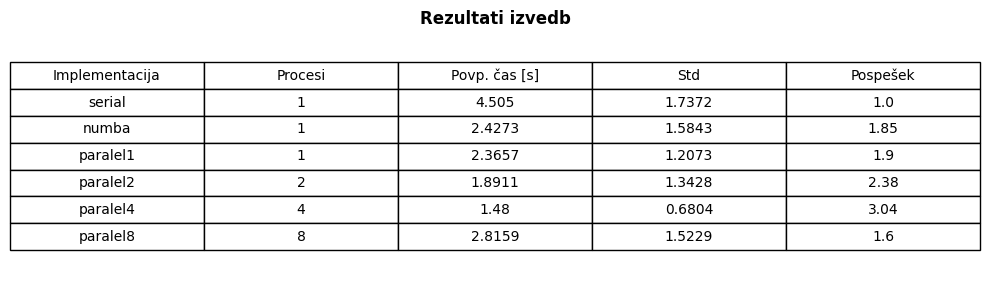

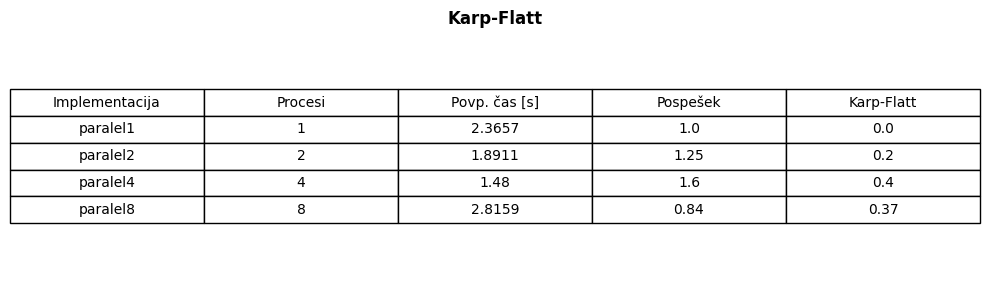

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

df_left = pd.DataFrame({
    "Implementacija": ["serial","numba","paralel1","paralel2","paralel4","paralel8"],
    "Procesi": [1,1,1,2,4,8],
    "Povp. čas [s]": [4.5050,2.4273,2.3657,1.8911,1.4800,2.8159],
    "Std": [1.7372,1.5843,1.2073,1.3428,0.6804,1.5229],
    "Pospešek": [1.00,1.85,1.90,2.38,3.04,1.60]
})

df_right = pd.DataFrame({
    "Implementacija": ["paralel1","paralel2","paralel4","paralel8"],
    "Procesi": [1,2,4,8],
    "Povp. čas [s]": [2.3657,1.8911,1.4800,2.8159],
    "Pospešek": [1.00,1.25,1.60,0.84],
    "Karp-Flatt": [0.00,0.20,0.40,0.37]
})

def save_table_image(df, filename, title):
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.axis('off')
    table = ax.table(cellText=df.values, colLabels=df.columns, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)
    plt.title(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

save_table_image(df_left, "levi_del_tabele.png", "Rezultati izvedb")
save_table_image(df_right, "desni_del_tabele.png", "Karp-Flatt")

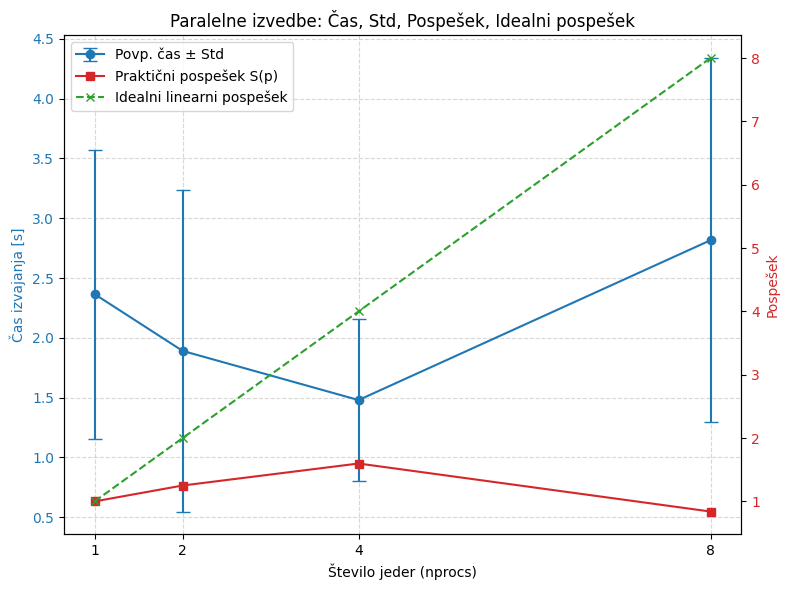

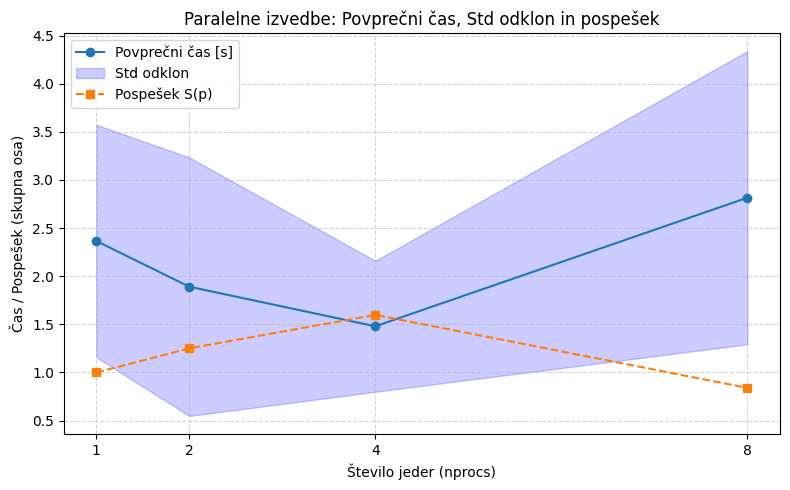

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

nprocs = np.array([1, 2, 4, 8])
avg_time = np.array([2.3657, 1.8911, 1.4800, 2.8159])
std = np.array([1.2073, 1.3428, 0.6804, 1.5229])
S_p = avg_time[0] / avg_time

plt.figure(figsize=(8,5))

plt.plot(nprocs, avg_time, 'o-', label='Povprečni čas [s]')
plt.fill_between(nprocs, avg_time - std, avg_time + std, color='blue', alpha=0.2, label='Std odklon')
plt.plot(nprocs, S_p, 's--', label='Pospešek S(p)')

plt.xlabel('Število jeder (nprocs)')
plt.ylabel('Čas / Pospešek (skupna osa)')
plt.title('Paralelne izvedbe: Povprečni čas, Std odklon in pospešek')
plt.xticks(nprocs)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()